In [ ]:
# This notebook can be used to process flight files and generate pickled files of correlator+drone data

In [2]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
import reduce as rc
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# Define any channels, etc, and directories for this flight analysis

#config_directory="  "
maindir = '/hirax/DNS_freespace/TONE_july_2025/'
dronedir = maindir+'processed_flight_records/'
cdir = maindir+'TONE_iceboard_files/corr_data/'
gdir = maindir+'TONE_iceboard_files/digital_gains/' 

# define which channels in the data files are useful
crmap = [0,3,4,6,7,8,9]
chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

# from crmap, which indices are autos, which indices are ref crosses
autos = [0,2,4,6]
crosses = [1,3,5]


# define default 'good' frequency for plotting
f_ind = 304 
freqs = np.arange(800,400,-400./1024)
print(freqs[f_ind])

###################
#### FUNCTIONS ####
###################

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))



681.25


## 1. Find Correspondence between drone flight file and correlator data

In [ ]:
# I'm putting this all in one cell (which won't run) now that the numbers are all stored

## 2. Capture in the yaml file - then can run everything below without above
#(Once it is in a yaml file, the above cells do not need to be run)

In [31]:
with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]

for f,fly in enumerate(flights):
    fly = flights[f]
    tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
    tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
    cdat = documents["flight_info"]["cdats"][f]
    tclb = documents["flight_info"]["tclbs"][f]
    tcub = documents["flight_info"]["tcubs"][f]
    fmax = documents["flight_info"]["fmaxes"][f]
    fmin = documents["flight_info"]["fmins"][f]
    descrip = documents["flight_info"]["desc"][f]
    pols = documents["flight_info"]["pols"][f]
    print(fly, cdat, tlb, tub, tclb, tcub, fmin,fmax,descrip,pols)

# airdata files are not very easily subscriptable, 
# cluge for now by knowing which flight order is in the yaml
f = 5


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print(fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)

Jul-14th-2025-10-14AM-Flight-Airdata.csv 20250714T135821Z_WVUc52 0 -1 0 -1 94 229 NS N
Jul-17th-2025-12-16PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11600 1680 27673 83 204 NS N
Jul-17th-2025-12-47PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 800 11300 2025 27061 256 375 NS N
Jul-17th-2025-01-51PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11600 1729 27718 612 730 NS E
Jul-17th-2025-04-07PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 800 10900 1929 26014 114 343 NS E
Jul-17th-2025-04-39PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 700 11500 1698 27449 404 520 EW N
Jul-17th-2025-07-56PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1734 27485 59 184 NW N
Jul-17th-2025-08-47PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1916 27672 343 466 NW N
Jul-18th-2025-11-49AM-Flight-Airdata.csv 20250718T152104Z_WVUc52 700 11500 1795 27547 153 280 NW N
Jul-18th-2025-12-21PM-Flight-Airdata.csv 20250718T152104Z_WVUc52 700 11500 1886 27637 335 456 EW E
Jul-18th-2025-12-53PM-Fl

Initializing drone data via Airdata.csv routine: Jul-17th-2025-04-39PM-Flight-Airdata.csv
  --> Skipping rows 1 to 1199 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-07-17 20:41:43+00:00 2025-07-17 20:59:42.900000+00:00


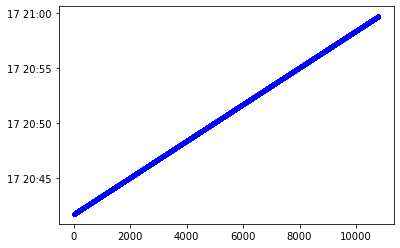

plotting drone coordinates for all time samples:
overplotting drone coordinates for t_cut samples: [0:-1]


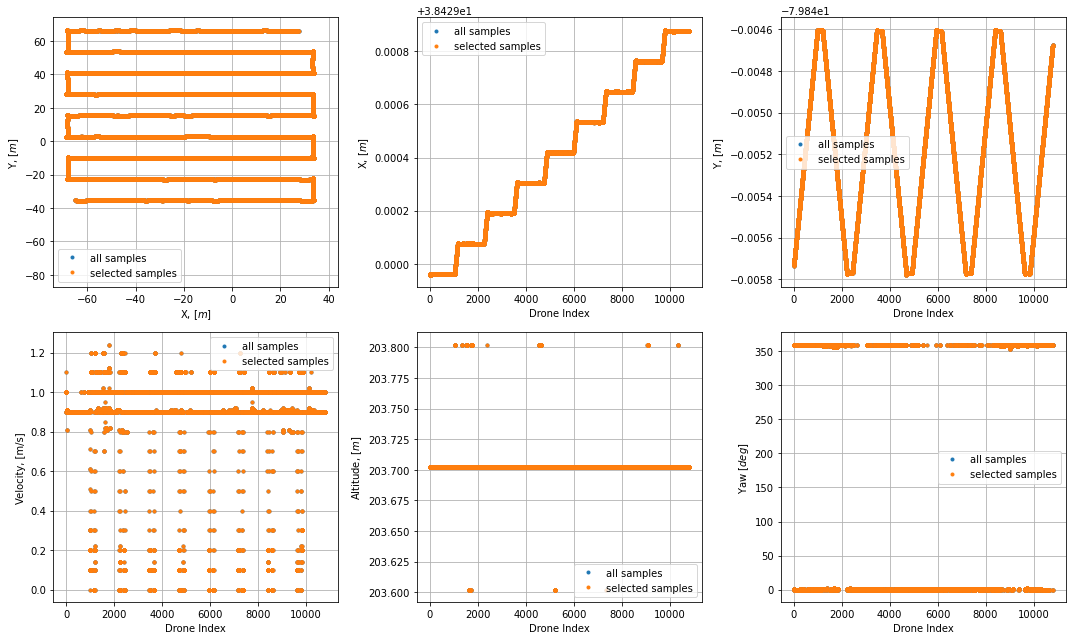

In [32]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronedata,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

start time:  2025-10-02 16:49:12.118423
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250717T192717Z_WVUc52/corr/20250717T192813Z/
  --> Arrays initialized with shape (116, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0519/0519
  --> Finished. Reshaping arrays.
end time:  2025-10-02 16:51:32.031440


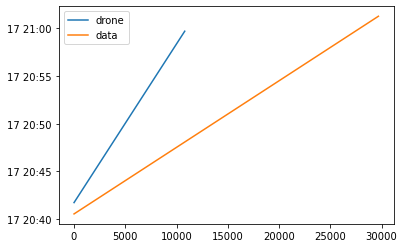

In [33]:
## Combine drone and correlator data
print('start time: ', datetime.datetime.now())

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=True,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmax)])

#corrdata=corr.Corr_Data(Data_Directory=datadir,
#                    Gain_Directory=gaindir,site_class=gbosite,
#                    Load_Gains=True,use_ctime=True,
#                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmin)+1])


    
print('end time: ', datetime.datetime.now())

## plot their datetime arrays to check overlap:

plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()


In [34]:
# Match drone and correlator data together, and plot a few frequencies

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)


In [35]:
## Bunches of plots to quickly look at the data
plotthis = False

if plotthis:
    print('Beam maps without any time correction or pulse calculation')
    for j in np.arange(0,len(crmap)):
        plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
                c=abs(concatdata.V_cross[:,f_ind,j]))
        plt.colorbar()
        plt.xlabel('X [m]')
        plt.ylabel('Y [m]')
        plt.title(chnames[j])
        plt.show()
    
    print('Plot the gains')
    # lets check gain application
    print(gaindir)
    gainfile=os.listdir(gaindir)[0]
    fg = h5py.File(gaindir+gainfile, 'r')
    gain_coeffs=fg['gain_coeff'][0] 
    gain_exp=fg['gain_exp'][0]
    digital_gain=fg['gain_coeff'][0] 
    digital_gain*=np.power(2,fg['gain_exp'][0])[np.newaxis,:]

    for j in np.arange(0,len(digital_gain[0,:])):
        plt.semilogy(freqs,digital_gain[:,j],label=str(j))
    plt.legend()
    plt.show()

    # plot waterfalls 

    print('Plotting waterfalls of autocorrelations')
    # waterfall of autos
    vmin=-100
    vmax=-92
    for j in autos:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()
    
    print('plotting waterfalls of dish x reference')
    # waterfall of crosses
    vmin=-140
    vmax=-100
    for j in crosses:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()

In [36]:
print(concatdata.V.shape)

(29696, 1024, 4)


In [37]:
## OBJECTIVE 5A: concat Function: Extract_Source_Pulses

## Let's use the Extract_Source_Pulses function:
    # The Period and Dutycycle options are known beforehand, and given in microseconds.
    # The t_bounds option just determines the plot bounds, not the solving routine.
## Fortunately, these parameters are loaded from the config, so we don't have to wait for the solver to run.
    ## The returned t_delta_pulse parameter will be given in seconds.
    ## In the verification plot, we should see the following points plotted:
        # orange_o = inds_off  = times when the source is off
        # blue_o   = inds_on   = times when the source is on and broadcasting
        # green_x  = inds_span = times where the behavior changes during the integration period (omit always!)
    ## The print statements shows the list of indices that appear in more than one of on/off/span.
        ## If they are all empty lists [], then there is no overlap which is a good thing.
concatdata.traceback=False
print('start time: ', datetime.datetime.now())
concatdata.Extract_Source_Pulses(Period=0.99999e6,Dutycycle=0.5e6,t_bounds=[0,-1],f_ind=f_ind, use_ref_channel=3)

print('end time: ', datetime.datetime.now())

start time:  2025-10-02 16:51:33.159098
PR MAX SOMETHING PER CHANNEL:  0 -0.6999899999999997
PR MAX SOMETHING PER CHANNEL:  1 -0.6969899999999997
PR MAX SOMETHING PER CHANNEL:  2 -0.7019899999999997
PR MAX SOMETHING PER CHANNEL:  3 -0.6909899999999997
end time:  2025-10-02 17:01:59.844057


13590 2517 13589


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


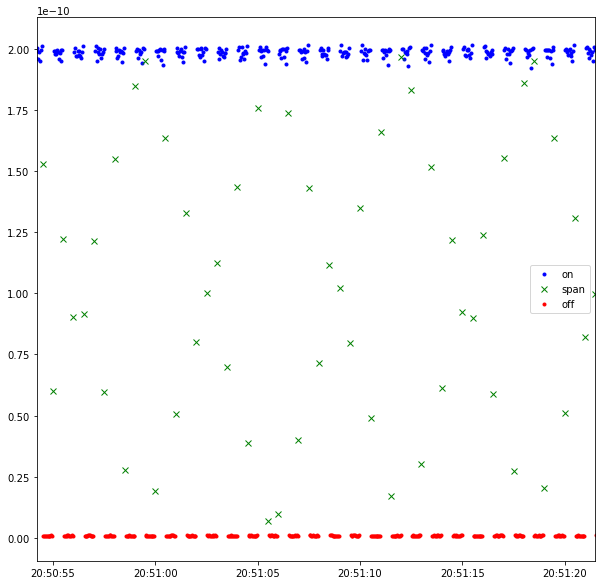

In [38]:
# aside to look at the span, on, and off indices in more detail

chind = 6
t_cut = concatdata.inds_on
t_span = concatdata.inds_span
t_off = concatdata.inds_off
N = len(t_cut)
N2 = int(N/2)
print(len(t_cut),len(t_span),len(t_off))
plt.figure(1,figsize=(10,10))

plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on')
plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,chind],'gx',label='span')
plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off')
plt.xlim(concatdata.t_arr_datetime[t_cut[N2]],concatdata.t_arr_datetime[t_cut[N2+300]])
plt.legend()
plt.show()

In [39]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
concatdata.Perform_Background_Subtraction(window_size=15)

In [40]:
print(concatdata.V_cross.shape)
print(concatdata.V_bgsub.shape)
print(concatdata.V_cross_bgsub.shape)
print(f_ind)
print(concatdata.t_index)

chind=0
print(abs(concatdata.V_cross[t_cut,f_ind,chind]))
print(abs(concatdata.V_cross[t_off,f_ind,chind]))
print(concatdata.V_cross_bgsub[t_cut,f_ind,chind])

nan_count_numpy = np.count_nonzero(np.isnan(concatdata.V_cross_bgsub[t_cut,f_ind,chind]))
print(f"NaN count in NumPy array: {nan_count_numpy}")

(29696, 1024, 7)
(29696, 1024, 4)
(29696, 1024, 7)
304
[    0     1     2 ... 29693 29694 29695]
[8.43835394e-11 8.50875723e-11 8.47466476e-11 ... 8.57098767e-11
 8.71109372e-11 8.54343348e-11]
[8.50583836e-11 8.41967314e-11 8.46730919e-11 ... 8.62796413e-11
 8.58569881e-11 8.58558205e-11]
[-1.93696616e-13+0.j  5.17118697e-13+0.j  2.39834316e-13+0.j ...
 -5.79529575e-14+0.j  1.34310755e-12+0.j -3.01695030e-13+0.j]
NaN count in NumPy array: 0


No handles with labels found to put in legend.


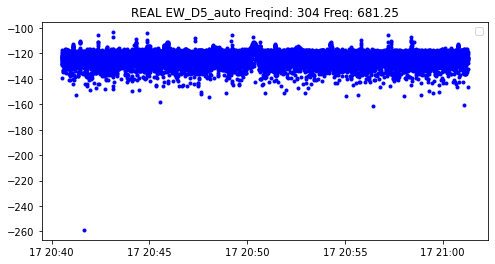

No handles with labels found to put in legend.


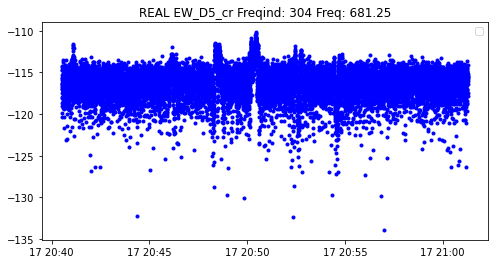

No handles with labels found to put in legend.


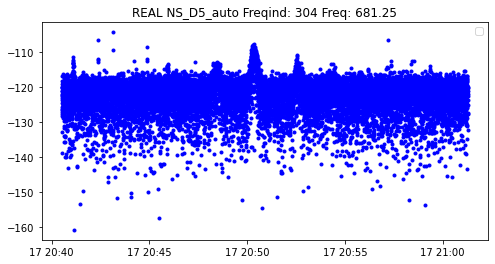

No handles with labels found to put in legend.


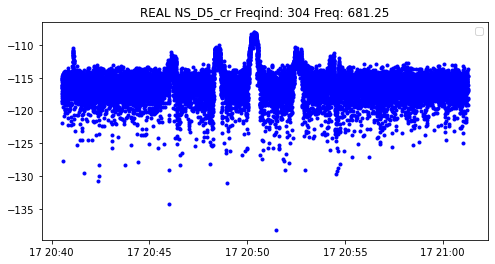

No handles with labels found to put in legend.


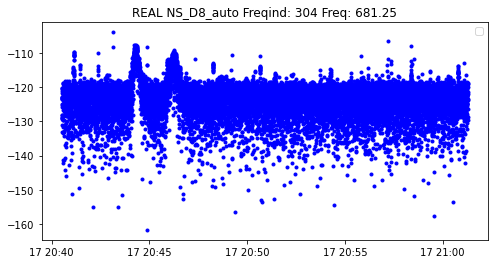

No handles with labels found to put in legend.


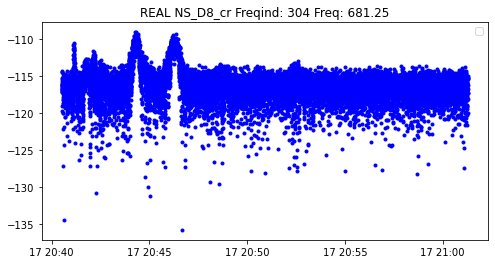

No handles with labels found to put in legend.


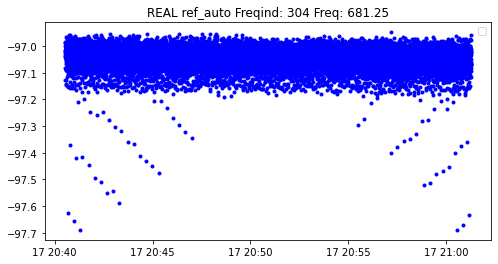

In [41]:
for chind in np.arange(0,len(crmap)):
    fig=figure(figsize=(8,4))
    plt.plot(concatdata.t_arr_datetime[t_cut],10*np.log10(abs(concatdata.V_cross_bgsub[t_cut,f_ind,chind])),'b.')
    #plt.xlim(tclb,tcub)
    plt.title('REAL '+chnames[chind] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/axes/_axes.py:4263: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


Plotting waterfalls of autocorrelations
0


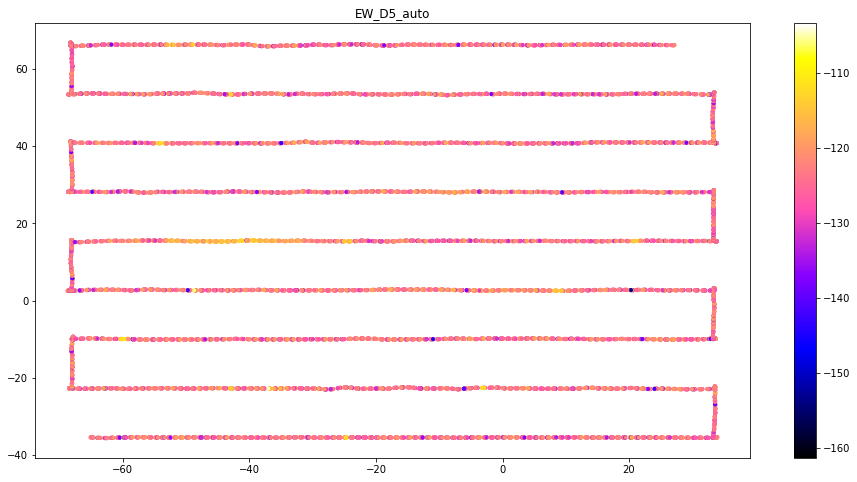

2


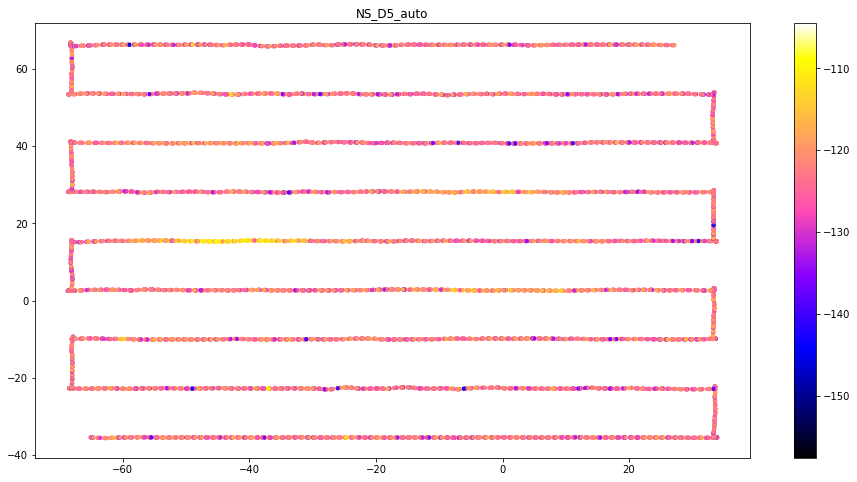

4


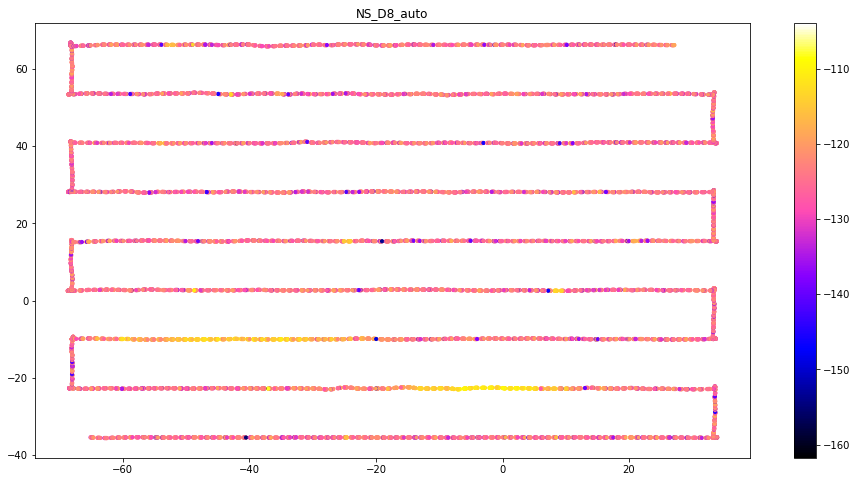

6


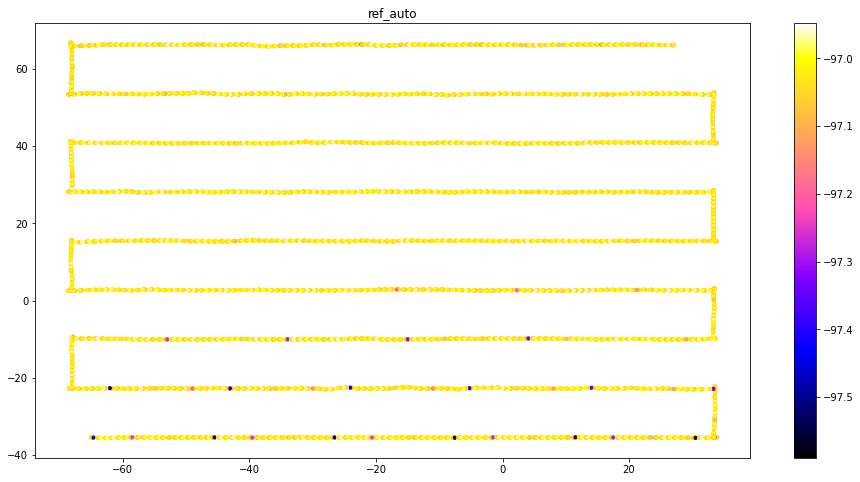

In [42]:
# waterfall of autos
print('Plotting waterfalls of autocorrelations')
# waterfall of autos

for chind in autos:
    print(chind)
    fig=figure(figsize=(16,8))
    plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_cross_bgsub[t_cut,f_ind,chind]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(tclb,tcub)
    plt.title(chnames[chind])
    plt.colorbar()
    plt.show()

#print('plotting waterfalls for crosses')
## waterfall of crosses
#vmin=-140
#vmax=-100
#for chind in crosses:
#    fig=figure(figsize=(16,8))
#    plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,chind])),aspect='auto',vmin=vmin,vmax=vmax)
#    #plt.xlim(tclb,tcub)
#    plt.title(chnames[chind])
#    plt.colorbar()
#    plt.show()

<ipython-input-43-3cbfc7a29808>:4: RuntimeWarning: invalid value encountered in log10
  c=10*np.log10(concatdata.V_bgsub[t_cut,f_ind,chind]),s=10.0,


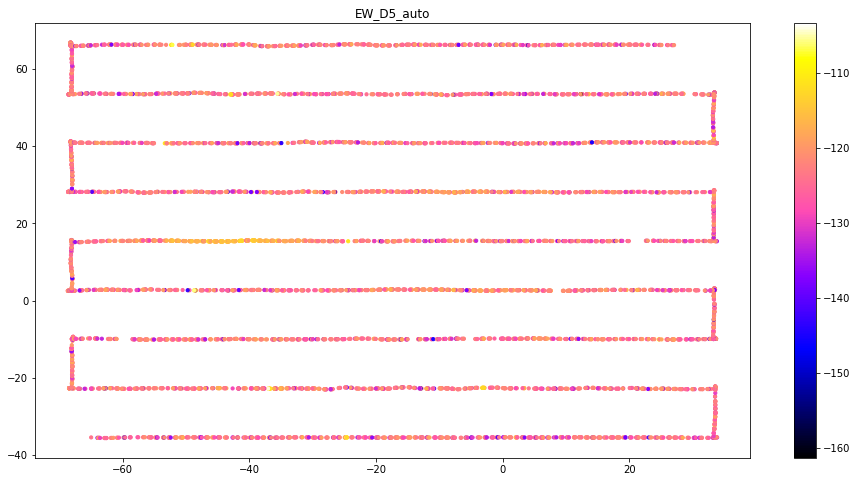

In [43]:
chind = 0
fig=figure(figsize=(16,8))
plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_bgsub[t_cut,f_ind,chind]),s=10.0,
            cmap='gnuplot2')
#plt.xlim(tclb,tcub)
plt.title(chnames[chind])
plt.colorbar()
plt.show()

In [44]:
## OBJECTIVE 5C: concat Function: Synchronization_Function

## This function finds the absolute timing shift between the dji data from the drone and the correlator
    ## We will be loading t_delta_dji from the config file to save some time!
    ## This function only works if the source was pulsed and if V_bgsub was created using background subtraction.
    ## This function works by zooming into the gaussian main beam and removing saturated data points...
## To run, you must give the following:
    ## inputcorr  = the corr class used in the concat
    ## inputdrone = the drone class used in the concat
## The optional parameters and their default values are listed below:
    ## coarse_params=[-10.0,10.0,0.2]    = the min,max,step parameters for the coarse time offset array
    ## fine_params=[-0.5,0.5,0.01]       = the min,max,step parameters for the fine time offset array
    ## chans=np.arange(0,2)              = the channels to fit. 0,1 gives us each polarization
    ## freqs=np.arange(100,1024,150)     = the min,max,step parameters for the freq array axis
    ## FMB_coordbounds=[50.0,50.0,150.0] = the cartesian coords we restrict around the main beam
        # x within +/- 50m from dish center in Local Cartesian (LC)
        # y within +/- 50m from dish center in Local Cartesian (LC)
        # z > 150m from dish center in Local Cartesian (LC)
    ## FMB_ampbound=0.999                = amplitude percentile threshold for saturation... 
        # time indices where the amplitude exceeds 0.999*maximum value are excluded because they are saturated

concatdata.Synchronization_Function(inputcorr=corrdata,inputdrone=dronedata,
                                        coarse_params=[-20.0,20.0,1],
                                        chans=np.array([0,1]),freqs=np.arange(304,305,1),
                                        FMB_coordbounds=[80.0,80.0,150.0],
                                        FMB_ampbound=0.999)

## Since we are loading from the config, we get to skip an iterative loop and just take the solution and apply it.
    ## The verification plot shown is hidden when traceback==False is set in the concat initialization
    ## Look closely at the verification plots to see which channel appears to be the co-pol (channel 1)
    ## In the bottom 2 panels, compare the fit result (white gaussian) to the data points (in color)
        ## We are omitting the saturated points to find the REAL max value, instead of squashing our peak
        ## If we are satisfied with this fit, we should try to save the parameters we found...

/home/ln267/anaconda3/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [45]:
print(concatdata.t_delta_dji)

-16.069999999999933


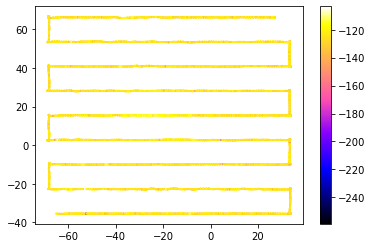

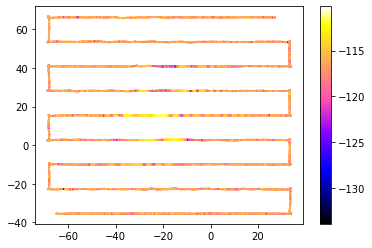

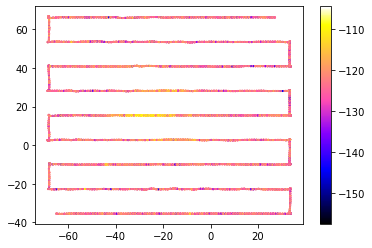

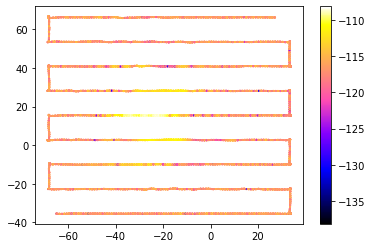

In [46]:
for chind in [0,1,2,3]:#np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_cross_bgsub[t_cut,f_ind,chind]),s=1.0,
            cmap='gnuplot2')
    #plt.xlim(-50,0)
    #plt.ylim(-20,40)
    plt.colorbar()
    plt.show()

In [47]:
# Do this to correct for 1/r^2 dependence

#concattest0825.Distance_Compensation(f_ind=900,plot_channels=[0])

In [48]:
## OBJECTIVE 5D: concat Function: Export_yaml

## When we have results we want to save, we should export our results to a config file for future use:
    ## The file will be written to the directory stated when the concat class was initialized.
    ## If a concat config yaml file already exists, a new version will be saved.
## Uncomment this if you want to export a config file... 


#concatdata5.Export_yaml()

In [49]:
## OBJECTIVE 5E: concat Function: Main_Beam_Fitting

## Now we can do some analysis, since we have synchronized useful data. We can begin by fitting the main beam:
    ## You can specify the directory where you want the fit params to be output:
    ## fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/'
    ## This one sometimes takes a while, feel free to get a coffee or something.
concatdata.Main_Beam_Fitting(fit_param_directory=maindir+'main_beam_fits/',freqs=np.arange(0,512,1),
                                 coordbounds=[80.0,80.0,150.0],
                                 FMB_ampbound=0.999,
                                 Vargs='bgsub')

print(concatdata.G_popt.shape)

/home/ln267/anaconda3/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


(4, 512, 7)


In [50]:
print(concatdata.G_popt[0,f_ind,:])

[ 2.66465534e-13 -3.82443835e+01 -8.61226279e-01  1.59689381e+01
  3.21510327e+00 -2.70920874e-13  0.00000000e+00]


In [51]:
plotthis = False

if plotthis:
    if concatdata.traceback==True:
        # copy and paste the file list above to make a plot
        ## this is your first glance at whether the Gaussian fits make sense across frequency for all channels
        ## these are grouped by polarization: small dots are one pol, big dots are the other
        filelist=['FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz']
        pu.plot_MBG_fits(filelist,cmp='gnuplot2')
    
    markers = ['s','v','^','>','P','x','+','o']
    colors=['red','orange','yellow','green','blue','purple','pink']

    fits = np.load('/hirax/GBO_Analysis_Outputs/main_beam_fits/FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz')
    pols=[0,2,8,10,14]
    freqs = np.arange(800,400,-400/1024)

    # amp
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,0],markersize=4,color=colors[pp],label=str(p))
    plt.title('Amplitude')
    plt.legend()
    plt.ylim(0,1.5E-7)
    plt.show()

    # X width
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,2],markersize=4,marker='.',color=colors[pp],linestyle='None',label=str(p))
    plt.title('X width')
    plt.legend()
    plt.ylim(4,15)
    plt.show()

    # Y width
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,4],markersize=4,marker='.',linestyle='None',color=colors[pp],label=str(p))
    plt.title('Y width')
    plt.legend()
    plt.ylim(4,17)
    plt.show()

    # X center
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,1],markersize=4,color=colors[pp],label=str(p))
    plt.title('X center')
    plt.legend()
    #plt.ylim(4,14)
    plt.show()

    # Y center
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,3],markersize=4,color=colors[pp],label=str(p))
    plt.title('Y center')
    plt.legend()
    #plt.ylim(4,14)
    plt.show()


In [52]:
# write out to a pickle file, name is autogenerated in the Smallify class

thingy = rc.Smallify(concatdata,pickle_directory=maindir)
print(thingy.tmppath)
with open(thingy.tmppath, 'wb') as outp:
    pickle.dump(thingy, outp, pickle.HIGHEST_PROTOCOL)
print('DONE')

/hirax/DNS_freespace/TONE_july_2025/flight_pickles/Jul-17th-2025-04-39PM_20250717T192717Z_WVUc52_ver_20251002T170942_concat.pkl
DONE


In [53]:
radfile = thingy.tmppath
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    ptest = pickle.load(inp)



Loading:  /hirax/DNS_freespace/TONE_july_2025/flight_pickles/Jul-17th-2025-04-39PM_20250717T192717Z_WVUc52_ver_20251002T170942_concat.pkl


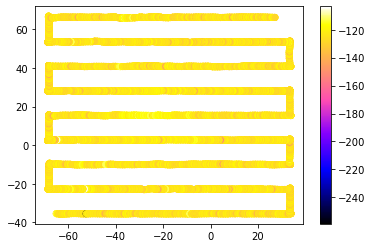

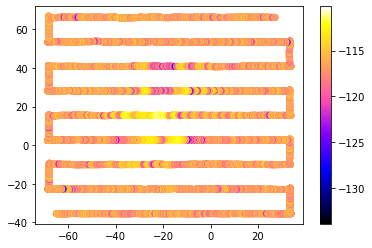

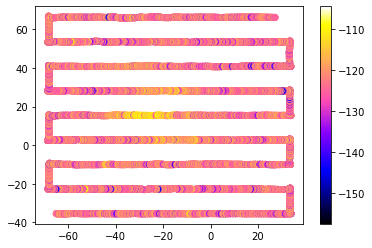

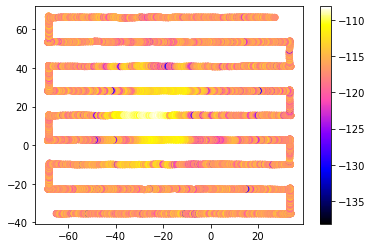

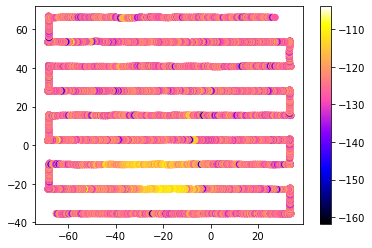

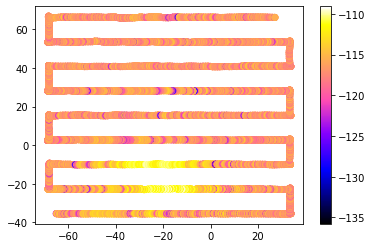

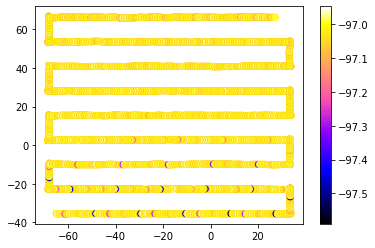

In [54]:
for chind in np.arange(0,len(crmap)):
    plt.scatter(ptest.drone_xyz_LC_interp[ptest.inds_on,0],ptest.drone_xyz_LC_interp[ptest.inds_on,1],
               c=10*np.log10(ptest.V_cross_bgsub[ptest.inds_on,f_ind,chind]), cmap='gnuplot2')
    plt.colorbar()
    plt.show()
